In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline 

In [2]:
words=open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocab of characters and mapping to/from integers
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi["."]=0
itos={i:s for s,i in stoi.items()}
vocab_size=len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# building the dataset 
block_size=3 #context length: how many characters do we take to predict the next one?

def build_datasets(words):
    X,Y = [],[]
    for w in words:
        context=[0] * block_size
        for ch in w + "." :
            ix= stoi[ch]
            X.append(context)
            Y.append(ix)
            context= context[1:]+ [ix] # crop and append

    X= torch.tensor(X)
    Y= torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

import random 
random.seed(42)

random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))

Xtr, Ytr= build_datasets(words[:n1]) # 80%
Xdev,Ydev=build_datasets(words[n1:n2]) # 10%
Xte,Yte=build_datasets(words[n2:]) # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# MLP revisited 
n_embd=10 #the dimensionality of the character embedding vectors 
n_hidden =200# the number of neurons in the hidden layer of the MLP

g=torch.Generator().manual_seed(2147483647) # for reproducibility
C= torch.randn((vocab_size,n_embd),    generator=g)
W1=torch.randn((n_embd* block_size,n_hidden),generator=g) *0.2
b1= torch.randn(n_hidden,              generator=g) * 0.01
W2= torch.randn((n_hidden,vocab_size), generator=g) * 0.01
b2=torch.randn(vocab_size,             generator=g) * 0

parameters =[C,W1,b1,W2,b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total 

for p in parameters:
    p.requires_grad= True

11897


tensor(0.0033) tensor(0.9889)
tensor(-0.0001) tensor(0.9760)


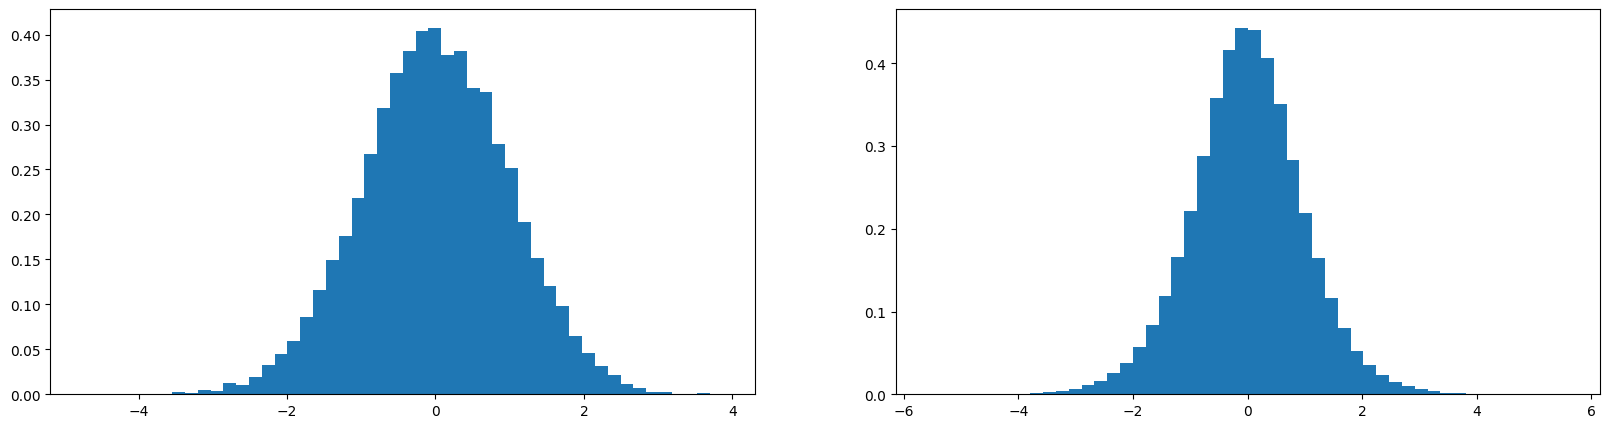

In [7]:
x= torch.randn(1000,10)
w = torch.randn(10,200) / 10**0.5
y= x @ w
print(x.mean(),x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50,density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True);

In [8]:
max_steps = 200000
batch_size=32
lossi=[]
for i in range(max_steps):
    #minibatch construct 
    ix=torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb,Yb =Xtr[ix],Ytr[ix] # batch X,Y

    # foward pass
    emb = C[Xb] #embed the characters into vectors 
    embcat= emb.view(emb.shape[0],-1)
    hpreact=embcat @ W1 + b1 # hidden layer pre-activation 
    h = torch.tanh(hpreact) # hidden layer 
    logits = h @ W2 + b2 # output layer 
    loss = F.cross_entropy(logits,Yb)
    for p in parameters:
        p.grad=None
    loss.backward()

    # update
    lr =0.1 if i< 100000 else 0.01 # step learning rate decay 
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 ==0: # prints every once in a while 
        print(f"{i:7d}/{max_steps:7d}: {loss.item():4f}")
    lossi.append(loss.log10().item())
    # break 

      0/ 200000: 3.313459
  10000/ 200000: 2.164827
  20000/ 200000: 2.306088
  30000/ 200000: 2.454139
  40000/ 200000: 1.978676
  50000/ 200000: 2.292973
  60000/ 200000: 2.423231
  70000/ 200000: 2.067998
  80000/ 200000: 2.309545
  90000/ 200000: 2.120710
 100000/ 200000: 1.826862
 110000/ 200000: 2.204487
 120000/ 200000: 1.979655
 130000/ 200000: 2.394567
 140000/ 200000: 2.100046
 150000/ 200000: 2.194798
 160000/ 200000: 1.861943
 170000/ 200000: 1.780918
 180000/ 200000: 1.967288
 190000/ 200000: 1.829461


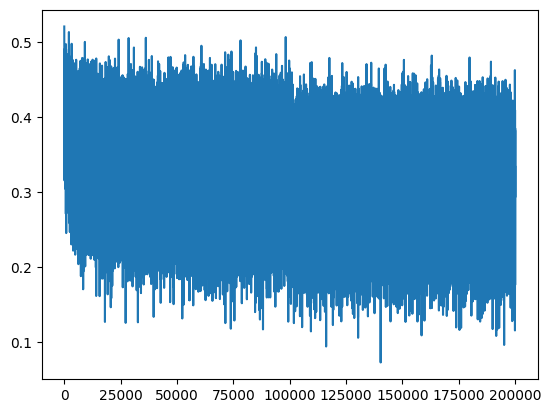

In [9]:
plt.plot(lossi)

In [10]:
@torch.no_grad() # this decorator disables gradient tracking 
def split_loss(split):
    x,y ={
        "train": (Xtr,Ytr),
        "val": (Xdev,Ydev),
        "test": (Xte,Yte),
    }[split]
    emb=C[x] # (N, block_size, n_embd)
    embcat=emb.view(emb.shape[0],-1) # concat into (N, block_size * n_embd)
    h= torch.tanh(embcat @ W1+b1) #(N,n_hidden)
    logits=h @ W2 + b2 #(N,vocab_size)
    loss=F.cross_entropy(logits, y)
    print(split,loss.item())

split_loss('train')
split_loss('val')

train 2.0355966091156006
val 2.1026785373687744


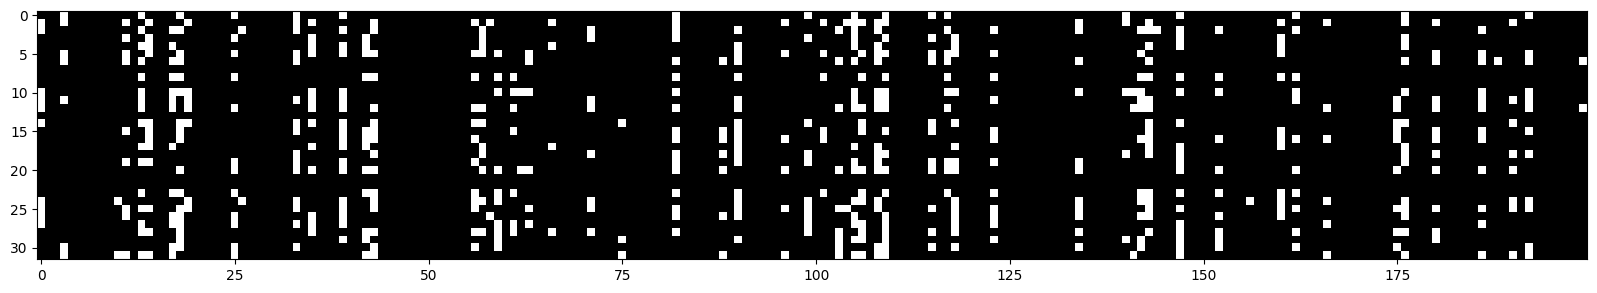

In [74]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap="gray",interpolation="nearest")

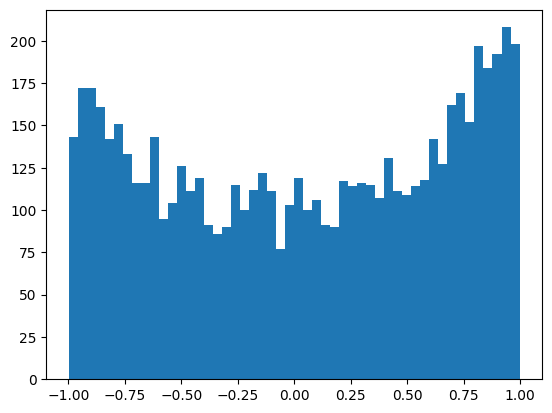

In [66]:
plt.hist(h.view(-1).tolist(),50);

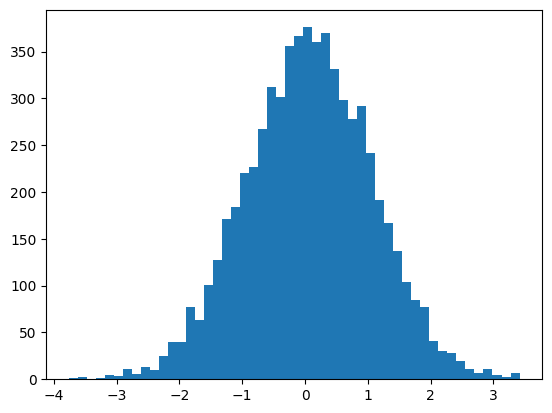

In [67]:
plt.hist(hpreact.view(-1).tolist(),50);

In [43]:
logits[0]

tensor([-1.0600,  2.1998, -0.7927, -1.1303, -0.5932,  2.3950, -1.9973, -1.5202,
        -0.1451,  2.8294, -1.6500, -1.5984,  2.6142,  1.6810,  3.6651,  1.6566,
        -0.3126, -5.8549,  1.8090,  1.4926,  0.5693, -0.3620,  0.6514, -2.1699,
        -3.9021,  2.7863,  0.1014], grad_fn=<SelectBackward0>)

In [44]:
# 4 dimensional example of the issue 
# logits = torch.tensor([0.0,0.0,0.0,0.0])
logits =torch.randn(4)*100
probs=torch.softmax(logits,dim=0)
loss = -probs[2].log()
logits,probs,loss

(tensor([-77.4945,  -5.8868,  78.0011, 125.9982]),
 tensor([0.0000e+00, 0.0000e+00, 1.4292e-21, 1.0000e+00]),
 tensor(47.9972))

In [45]:
# ideal loss 
-torch.tensor(1/27).log()

tensor(3.2958)

In [13]:
#sample from the model
g=torch.Generator().manual_seed(2147483647+10)
for _ in range(20):
    out=[]
    context=[0] * block_size #initialize with all....
    while True:
        # foward pass the neural net
        emb=C[torch.tensor([context])] # (1, block_size,n_embd)
        h= torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs= F.softmax(logits, dim=1)
        # sample from the distribution 
        ix=torch.multinomial(probs, num_samples=1,generator=g).item()
        #shift the context window and track the samples 
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token ,break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print the generated word 

carlah.
amille.
khirmoni.
taty.
skanden.
jazhubedlee.
art.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
jorn.
quinn.
salin.
alianni.
wavero.
dearynix.
kaelisseli.
edde.
